In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Cargar datos desde las listas

In [2]:
# Rutas
lists_dir = Path('../data/lists')

# Cargar mapeo de etiquetas
with open(lists_dir / 'label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

# Invertir el mapeo para obtener nombres desde índices
idx_to_label = {v: k for k, v in label_mapping.items()}

print("Mapeo de etiquetas:")
print(label_mapping)
print("\nÍndices a etiquetas:")
print(idx_to_label)

Mapeo de etiquetas:
{'Benign': 0, 'Malignant': 1}

Índices a etiquetas:
{0: 'Benign', 1: 'Malignant'}


In [3]:
# Función para cargar datos desde archivos .txt
def load_split_data(file_path):
    """
    Carga los datos de un archivo .txt que contiene rutas de imágenes y etiquetas.
    
    Args:
        file_path: Ruta al archivo .txt
    
    Returns:
        DataFrame con columnas 'image_path' y 'label'
    """
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) == 2:
                    image_path, label = parts
                    data.append({
                        'image_path': image_path,
                        'label': int(label),
                        'class_name': idx_to_label[int(label)]
                    })
    return pd.DataFrame(data)

# Cargar todos los conjuntos
train_df = load_split_data(lists_dir / 'train.txt')
val_df = load_split_data(lists_dir / 'validation.txt')
test_df = load_split_data(lists_dir / 'test.txt')

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Total samples: {len(train_df) + len(val_df) + len(test_df)}")

Train samples: 46840
Validation samples: 11336
Test samples: 17125
Total samples: 75301


## 2. Análisis de distribución de clases

In [4]:
# Función para calcular estadísticas de balance
def analyze_class_balance(df, split_name):
    """
    Analiza el balance de clases en un conjunto de datos.
    
    Args:
        df: DataFrame con los datos
        split_name: Nombre del conjunto (train, val, test)
    
    Returns:
        DataFrame con estadísticas
    """
    class_counts = df['class_name'].value_counts().sort_index()
    total = len(df)
    
    stats = pd.DataFrame({
        'Clase': class_counts.index,
        'Cantidad': class_counts.values,
        'Porcentaje': (class_counts.values / total * 100).round(2),
        'Conjunto': split_name
    })
    
    # Calcular ratio de desbalance
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count
    
    print(f"\n{'='*60}")
    print(f"Análisis de {split_name.upper()}")
    print(f"{'='*60}")
    print(stats.to_string(index=False))
    print(f"\nRatio de desbalance: {imbalance_ratio:.2f}:1")
    print(f"Clase mayoritaria: {class_counts.idxmax()} ({class_counts.max()} muestras)")
    print(f"Clase minoritaria: {class_counts.idxmin()} ({class_counts.min()} muestras)")
    
    return stats

# Analizar cada conjunto
train_stats = analyze_class_balance(train_df, 'Train')
val_stats = analyze_class_balance(val_df, 'Validation')
test_stats = analyze_class_balance(test_df, 'Test')


Análisis de TRAIN
    Clase  Cantidad  Porcentaje Conjunto
   Benign     38239       81.64    Train
Malignant      8601       18.36    Train

Ratio de desbalance: 4.45:1
Clase mayoritaria: Benign (38239 muestras)
Clase minoritaria: Malignant (8601 muestras)

Análisis de VALIDATION
    Clase  Cantidad  Porcentaje   Conjunto
   Benign      9561       84.34 Validation
Malignant      1775       15.66 Validation

Ratio de desbalance: 5.39:1
Clase mayoritaria: Benign (9561 muestras)
Clase minoritaria: Malignant (1775 muestras)

Análisis de TEST
    Clase  Cantidad  Porcentaje Conjunto
   Benign     15067       87.98     Test
Malignant      2058       12.02     Test

Ratio de desbalance: 7.32:1
Clase mayoritaria: Benign (15067 muestras)
Clase minoritaria: Malignant (2058 muestras)


## 3. Visualización de la distribución de clases

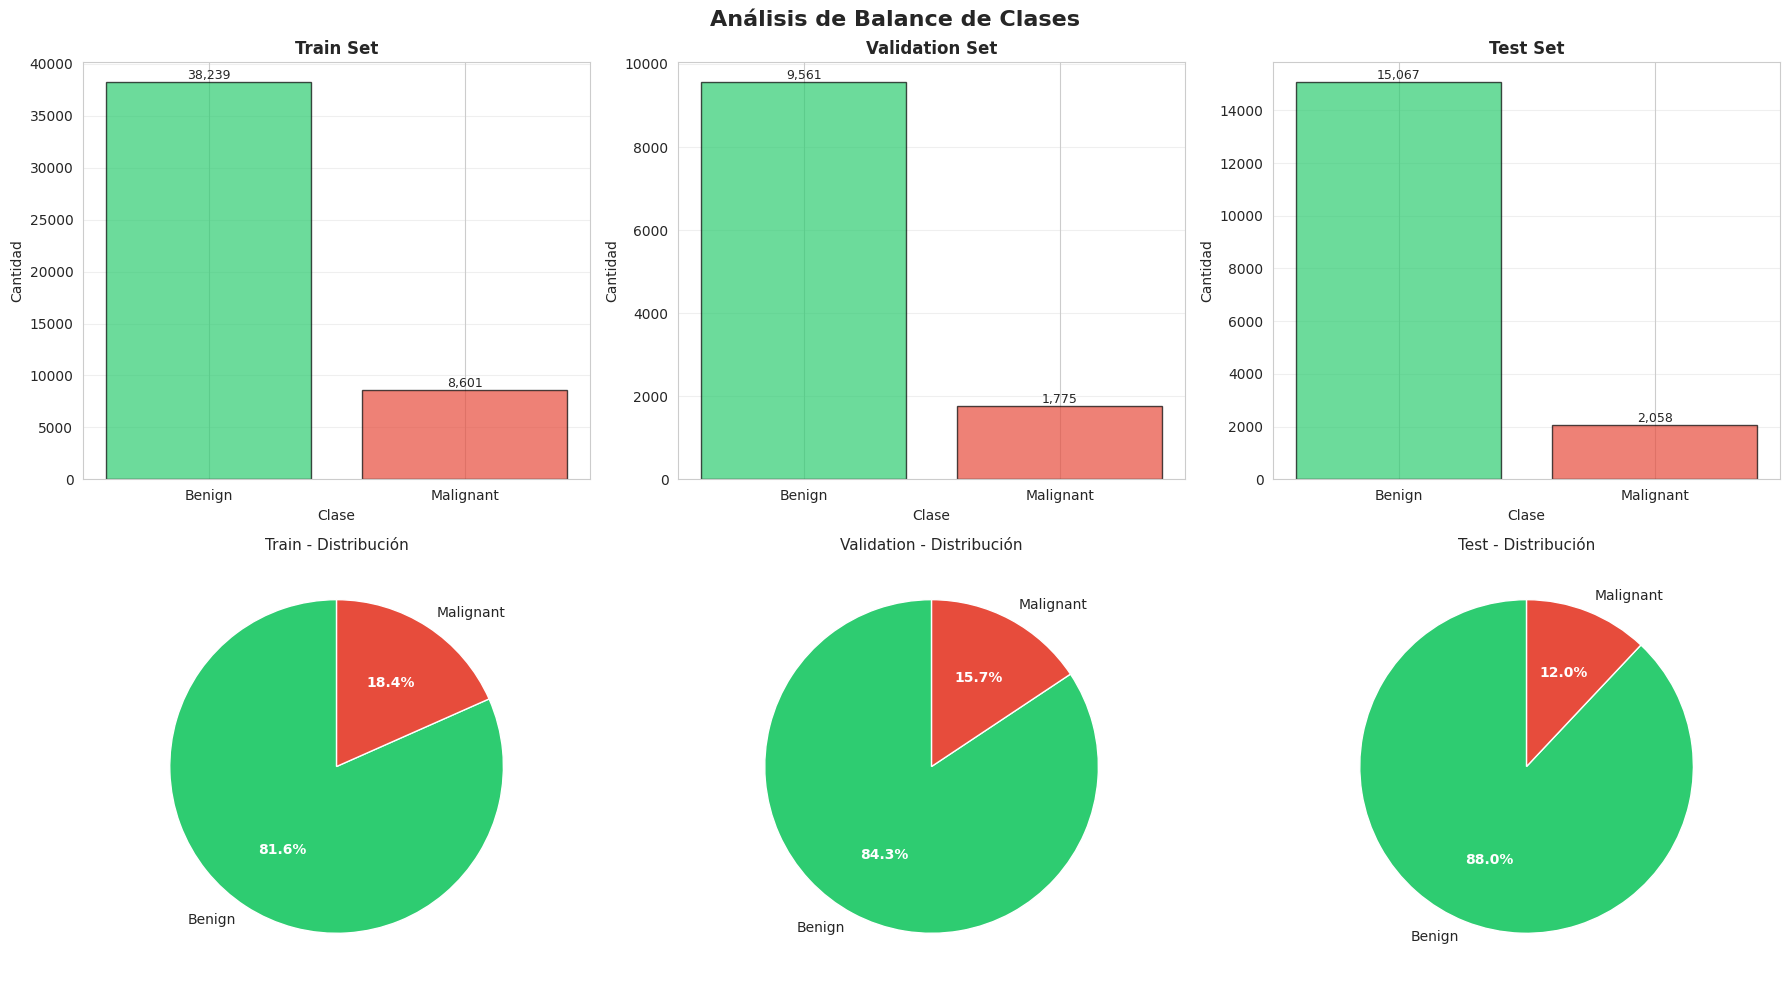

In [5]:
# Combinar estadísticas
all_stats = pd.concat([train_stats, val_stats, test_stats], ignore_index=True)

# Crear figura con múltiples subgráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis de Balance de Clases', fontsize=16, fontweight='bold')

# Colores para las clases
colors = {'Benign': '#2ecc71', 'Malignant': '#e74c3c'}

# Gráficos de barras para cada conjunto
datasets = [('Train', train_df, 0), ('Validation', val_df, 1), ('Test', test_df, 2)]

for name, df, idx in datasets:
    ax = axes[0, idx]
    class_counts = df['class_name'].value_counts()
    bars = ax.bar(class_counts.index, class_counts.values, 
                   color=[colors[c] for c in class_counts.index],
                   alpha=0.7, edgecolor='black')
    
    ax.set_title(f'{name} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase', fontsize=10)
    ax.set_ylabel('Cantidad', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Agregar valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

# Gráficos de pie para porcentajes
for name, df, idx in datasets:
    ax = axes[1, idx]
    class_counts = df['class_name'].value_counts()
    
    wedges, texts, autotexts = ax.pie(class_counts.values, 
                                        labels=class_counts.index,
                                        autopct='%1.1f%%',
                                        colors=[colors[c] for c in class_counts.index],
                                        startangle=90,
                                        textprops={'fontsize': 10})
    
    # Mejorar el texto de los porcentajes
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(f'{name} - Distribución', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Comparación entre conjuntos

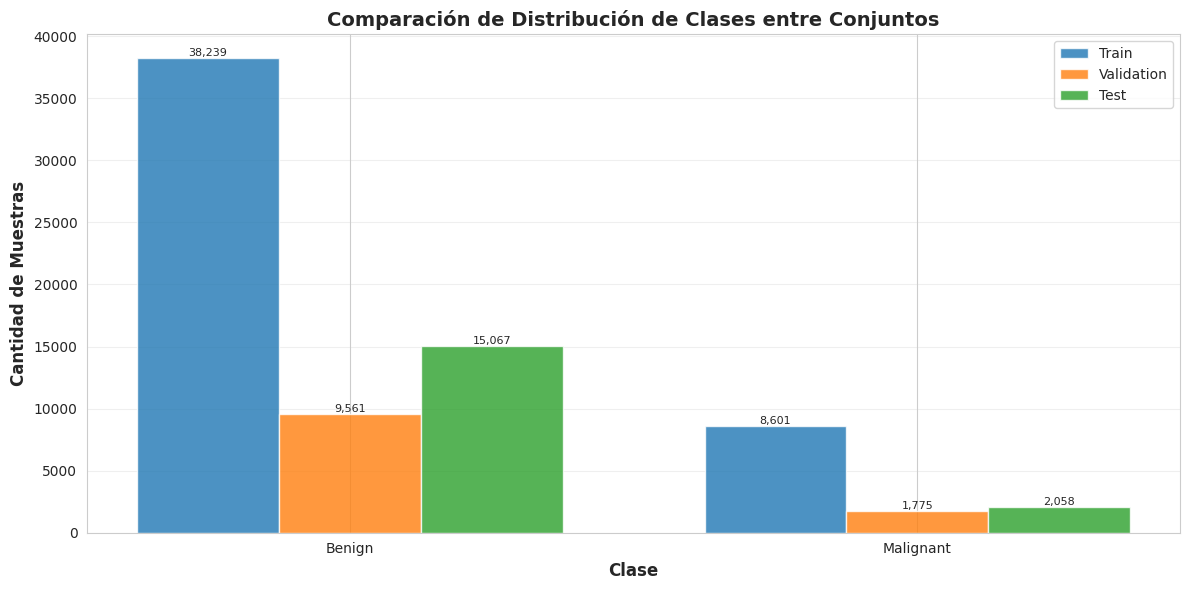

In [6]:
# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(['Benign', 'Malignant']))
width = 0.25

for i, (name, df) in enumerate([('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    class_counts = df['class_name'].value_counts().sort_index()
    offset = width * (i - 1)
    bars = ax.bar(x + offset, class_counts.values, width, 
                   label=name, alpha=0.8)
    
    # Agregar valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Clase', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Muestras', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Distribución de Clases entre Conjuntos', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Benign', 'Malignant'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Tabla resumen completa

In [7]:
# Crear tabla resumen
summary_data = []

for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    class_counts = df['class_name'].value_counts().sort_index()
    total = len(df)
    
    benign_count = class_counts.get('Benign', 0)
    malignant_count = class_counts.get('Malignant', 0)
    
    summary_data.append({
        'Conjunto': name,
        'Benign': benign_count,
        'Benign %': f"{(benign_count/total*100):.2f}%",
        'Malignant': malignant_count,
        'Malignant %': f"{(malignant_count/total*100):.2f}%",
        'Total': total,
        'Ratio': f"{(benign_count/malignant_count):.2f}:1"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("RESUMEN GENERAL - BALANCE DE CLASES")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


RESUMEN GENERAL - BALANCE DE CLASES
  Conjunto  Benign Benign %  Malignant Malignant %  Total  Ratio
     Train   38239   81.64%       8601      18.36%  46840 4.45:1
Validation    9561   84.34%       1775      15.66%  11336 5.39:1
      Test   15067   87.98%       2058      12.02%  17125 7.32:1


## 6. Cálculo de pesos de clase recomendados

In [8]:
# Calcular pesos de clase para el conjunto de entrenamiento
from sklearn.utils.class_weight import compute_class_weight

# Obtener las etiquetas del conjunto de entrenamiento
y_train = train_df['label'].values
classes = np.unique(y_train)

# Calcular pesos
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "="*60)
print("PESOS DE CLASE RECOMENDADOS (para entrenamiento)")
print("="*60)
for class_idx, weight in class_weight_dict.items():
    class_name = idx_to_label[class_idx]
    print(f"{class_name} (clase {class_idx}): {weight:.4f}")
print("\nEjemplo de uso en Keras:")
print(f"class_weight = {class_weight_dict}")
print("="*60)


PESOS DE CLASE RECOMENDADOS (para entrenamiento)
Benign (clase 0): 0.6125
Malignant (clase 1): 2.7229

Ejemplo de uso en Keras:
class_weight = {np.int64(0): np.float64(0.61246371505531), np.int64(1): np.float64(2.7229391931170794)}


## 7. Análisis de desbalance y recomendaciones

In [10]:
# Función para evaluar el nivel de desbalance
def evaluate_imbalance(ratio):
    if ratio < 1.5:
        return "Ligeramente desbalanceado", "green"
    elif ratio < 3:
        return "Moderadamente desbalanceado", "yellow"
    elif ratio < 5:
        return "Significativamente desbalanceado", "orange"
    else:
        return "Altamente desbalanceado", "red"

# Analizar el conjunto de entrenamiento
train_class_counts = train_df['class_name'].value_counts().sort_index()
train_ratio = train_class_counts.max() / train_class_counts.min()
imbalance_level, color = evaluate_imbalance(train_ratio)

print("\n" + "="*80)
print("DIAGNÓSTICO DE DESBALANCE")
print("="*80)
print(f"\nRatio de desbalance en entrenamiento: {train_ratio:.2f}:1")
print(f"Nivel: {imbalance_level}")
print("\nRECOMENDACIONES:")
print("-" * 80)

if train_ratio >= 3:
    print("⚠️  El dataset presenta desbalance significativo. Se recomienda:")
    print("   1. Usar class_weights durante el entrenamiento")
    print("   2. Considerar técnicas de data augmentation para la clase minoritaria")
    print("   3. Usar métricas balanceadas: F1-score, AUC-ROC, Precision-Recall")
    print("   4. Evaluar con matriz de confusión para detectar sesgos")
    print("   5. Considerar técnicas de oversampling (SMOTE) o undersampling")
else:
    print("✓ El desbalance es manejable con técnicas estándar")
    print("   1. Usar class_weights es suficiente")
    print("   2. Monitorear métricas balanceadas: F1-score, AUC-ROC")

print("="*80)


DIAGNÓSTICO DE DESBALANCE

Ratio de desbalance en entrenamiento: 4.45:1
Nivel: Significativamente desbalanceado

RECOMENDACIONES:
--------------------------------------------------------------------------------
⚠️  El dataset presenta desbalance significativo. Se recomienda:
   1. Usar class_weights durante el entrenamiento
   2. Considerar técnicas de data augmentation para la clase minoritaria
   3. Usar métricas balanceadas: F1-score, AUC-ROC, Precision-Recall
   4. Evaluar con matriz de confusión para detectar sesgos
   5. Considerar técnicas de oversampling (SMOTE) o undersampling


## 8. Visualización de ratios de desbalance

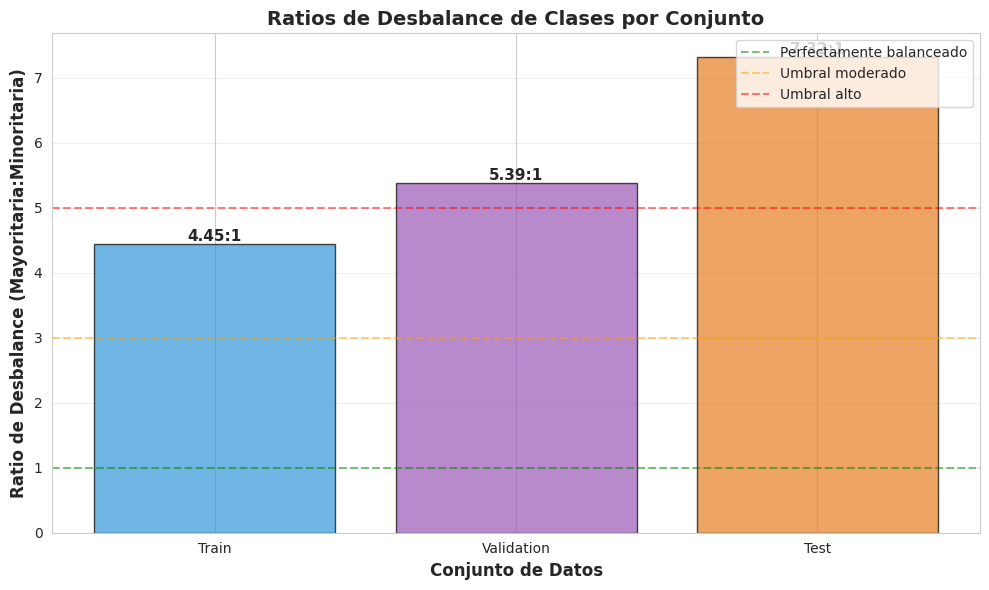

In [11]:
# Calcular ratios para cada conjunto
ratios = []
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    class_counts = df['class_name'].value_counts()
    ratio = class_counts.max() / class_counts.min()
    ratios.append({'Conjunto': name, 'Ratio': ratio})

ratios_df = pd.DataFrame(ratios)

# Gráfico de barras de ratios
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(ratios_df['Conjunto'], ratios_df['Ratio'], 
               color=['#3498db', '#9b59b6', '#e67e22'], alpha=0.7, edgecolor='black')

# Líneas de referencia
ax.axhline(y=1, color='green', linestyle='--', label='Perfectamente balanceado', alpha=0.5)
ax.axhline(y=3, color='orange', linestyle='--', label='Umbral moderado', alpha=0.5)
ax.axhline(y=5, color='red', linestyle='--', label='Umbral alto', alpha=0.5)

# Agregar valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}:1',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Conjunto de Datos', fontsize=12, fontweight='bold')
ax.set_ylabel('Ratio de Desbalance (Mayoritaria:Minoritaria)', fontsize=12, fontweight='bold')
ax.set_title('Ratios de Desbalance de Clases por Conjunto', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8.1. Visualización Detallada del Conjunto de Entrenamiento

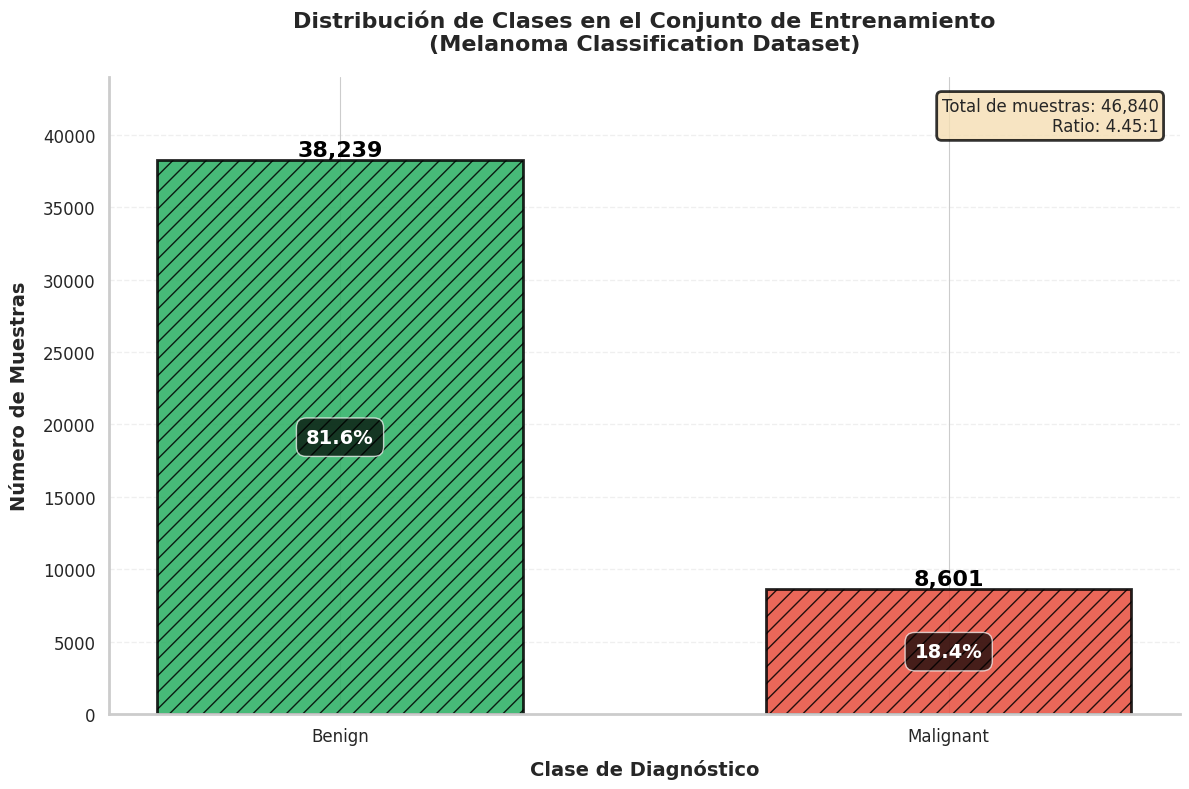


📊 ESTADÍSTICAS DETALLADAS DEL CONJUNTO DE ENTRENAMIENTO

      Benign: ██████████████████████████████████████████████████ 38,239 (81.64%)

   Malignant: ███████████ 8,601 (18.36%)



In [12]:
# Gráfico detallado y elegante solo para el conjunto de entrenamiento
fig, ax = plt.subplots(figsize=(12, 8))

# Obtener datos del conjunto de entrenamiento
train_class_counts = train_df['class_name'].value_counts().sort_index()
classes = train_class_counts.index
counts = train_class_counts.values

# Crear gradiente de colores
colors_gradient = ['#27ae60', '#e74c3c']  # Verde para Benign, Rojo para Malignant

# Crear barras con efecto de gradiente
bars = ax.bar(classes, counts, color=colors_gradient, alpha=0.85, 
               edgecolor='black', linewidth=2, width=0.6)

# Agregar textura de patrón
for bar, color in zip(bars, colors_gradient):
    bar.set_hatch('//')

# Agregar valores sobre las barras con formato elegante
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    percentage = (count / len(train_df)) * 100
    
    # Texto principal con el conteo
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=16, fontweight='bold',
            color='black')
    
    # Texto secundario con el porcentaje
    ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
            f'{percentage:.1f}%',
            ha='center', va='center', fontsize=14, fontweight='bold',
            color='white', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))

# Personalizar el gráfico
ax.set_xlabel('Clase de Diagnóstico', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Número de Muestras', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Distribución de Clases en el Conjunto de Entrenamiento\n(Melanoma Classification Dataset)', 
             fontsize=16, fontweight='bold', pad=20)

# Mejorar la cuadrícula
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Personalizar los ejes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Agregar información adicional en una caja de texto
textstr = f'Total de muestras: {len(train_df):,}\nRatio: {train_ratio:.2f}:1'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# Ajustar el límite del eje y para mejor visualización
ax.set_ylim(0, max(counts) * 1.15)

# Mejorar los ticks
ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)

plt.tight_layout()
plt.show()

# Imprimir estadísticas detalladas
print("\n" + "="*70)
print("📊 ESTADÍSTICAS DETALLADAS DEL CONJUNTO DE ENTRENAMIENTO")
print("="*70)
for class_name, count in train_class_counts.items():
    percentage = (count / len(train_df)) * 100
    bar_length = int((count / max(counts)) * 50)
    bar = "█" * bar_length
    print(f"\n{class_name:>12}: {bar} {count:,} ({percentage:.2f}%)")
print("\n" + "="*70)

## 9. Conclusiones

Este análisis proporciona:
- **Distribución detallada** de clases en cada conjunto (train, validation, test)
- **Ratios de desbalance** para identificar problemas potenciales
- **Pesos de clase recomendados** para usar durante el entrenamiento
- **Recomendaciones específicas** basadas en el nivel de desbalance detectado

### Próximos pasos sugeridos:
1. Implementar class_weights en el modelo
2. Usar métricas balanceadas para evaluación
3. Considerar data augmentation si el desbalance es severo
4. Monitorear el rendimiento por clase durante el entrenamiento